# ***Next Word Prediction: A Comparative study of Machine Learning and Deep Learning Approaches***

## 1. Library Imports

In [1]:
import os
import re
import string
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from collections import defaultdict

In [2]:
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import accuracy_score

In [3]:
# Deep Learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

2026-05-19 10:25:35.768600: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779186335.953453      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779186336.008857      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779186336.427663      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779186336.427701      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779186336.427703      57 computation_placer.cc:177] computation placer alr

In [4]:
# Visualization
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [5]:
print(f"TensorFlow version : {tf.__version__}")
print(f"GPU devices        : {tf.config.list_physical_devices('GPU')}")

TensorFlow version : 2.19.0
GPU devices        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Dataset Loading

In [6]:
df = pd.read_csv('/kaggle/input/datasets/praronanusrat/bookcorpus-50k/bookcorpus_50k.csv')
df = df[:25000]

print(f"Dataset shape : {df.shape}")
print(f"Columns : {list(df.columns)}")
print()
print(df.head())

Dataset shape : (25000, 1)
Columns : ['text']

                                                text
0  the half-ling book one in the fall of igneeria...
1  isbn : 1492913731 isbn-13 : 978-1492913733 for...
2    i wish i had a better answer to that question .
3  starlings , new york is not the place youd exp...
4  its a small quiet town , the kind where everyo...


## 3. Text Cleaning

*  **Lowercasing** — normalises character case.
*  **Unicode punctuation removal** — strips curly quotes, ellipses, and similar characters.
*  **Standard punctuation removal** — removes all ASCII punctuation.
*  **Digit removal** — eliminates numeric tokens irrelevant to next-word prediction.
*  **URL removal** — strips web addresses.
*  **Non-ASCII filtering** — removes characters outside the ASCII range.
*  **Whitespace normalisation** — collapses multiple spaces and trims edges.

In [7]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[""''\u2018\u2019\u201c\u201d\u2026]', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply cleaning
quotes = df['text'].dropna()
quotes = quotes[quotes.str.strip() != '']
quotes = quotes[~quotes.str.startswith(' =')]
quotes = quotes.apply(clean_text)
quotes = quotes[quotes.str.split().apply(len) > 2]
quotes = quotes.reset_index(drop=True)

#Output after cleaing
print(f"\nBefore cleaning : {len(df)}")
print(f"After cleaning  : {len(quotes)}")
print(quotes.head())


Before cleaning : 25000
After cleaning  : 23544
0    the halfling book one in the fall of igneeria ...
1    isbn isbn for my family who encouraged me to n...
2        i wish i had a better answer to that question
3    starlings new york is not the place youd expec...
4    its a small quiet town the kind where everyone...
Name: text, dtype: object


## 4. Train–Test Split(80/20)

In [8]:
train_quotes, test_quotes = train_test_split(
    quotes, test_size=0.2, random_state=42
)
# Reset index to create fresh sequential indexes after train_test_split
train_quotes = train_quotes.reset_index(drop=True)
test_quotes  = test_quotes.reset_index(drop=True)

#After split shape
print(f"Train Quotes shape : {train_quotes.shape}")
print(f"Test Quotes shape : {test_quotes.shape}")

Train Quotes shape : (18835,)
Test Quotes shape : (4709,)


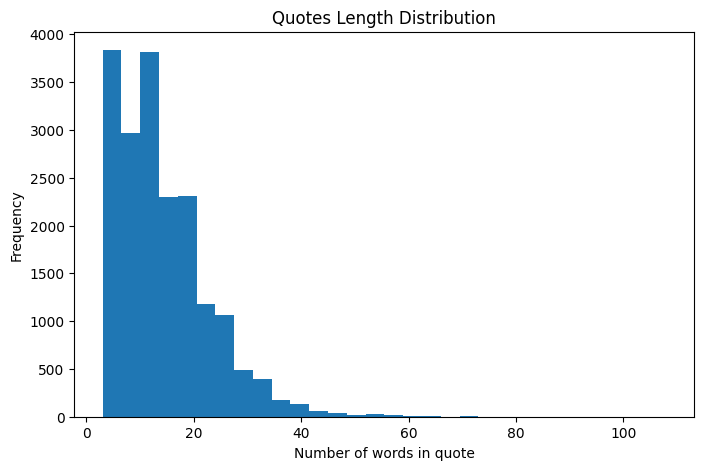

In [9]:
lengths = [len(q.split()) for q in train_quotes]
plt.figure(figsize=(8,5))
plt.hist(lengths, bins=30)
plt.title("Quotes Length Distribution")
plt.xlabel("Number of words in quote")
plt.ylabel("Frequency")
plt.show()

# ***Machine learning Models***

## 5. Naive Bayes Model

In [10]:
# Create dataset for next-word prediction
def build_nb_dataset(quote_series):
    X, y = [], []   # X = input contexts, y = target next words
    for sentence in quote_series:
        words = sentence.split()
        for i in range(1, len(words)):
            context = ' '.join(words[:i])
            X.append(context)
            y.append(words[i])
    return X, y

In [11]:
# Create training/test dataset
X_train_nb, y_train_nb = build_nb_dataset(train_quotes)
X_test_nb,  y_test_nb  = build_nb_dataset(test_quotes)

# Print total training and testing samples for Naive Bayes
print(f"Train samples (Naive Bayes) : {len(X_train_nb)}")
print(f"Test samples  (Naive Bayes) : {len(X_test_nb)}")

Train samples (Naive Bayes) : 243207
Test samples  (Naive Bayes) : 59933


In [12]:
# Convert text into TF-IDF numerical vectors
vectorizer = TfidfVectorizer(max_features=8000, min_df=2)
X_train_vec = vectorizer.fit_transform(X_train_nb)
X_test_vec = vectorizer.transform(X_test_nb)

In [13]:
# Create Naive Bayes classifier
nb_model = ComplementNB()
# Train model
nb_model.fit(X_train_vec, y_train_nb)

ComplementNB()

In [14]:
# Predict next words for test data
predictions = nb_model.predict(X_test_vec)

# Calculate prediction accuracy
nb_acc = accuracy_score(y_test_nb, predictions)
print(f"Naive Bayes Accuracy: {nb_acc * 100:.2f}%")

Naive Bayes Accuracy: 7.25%


In [15]:
# Function to predict next word
def predict_next_word_nb(text):
    text = clean_text(text)
    words = text.split()
    vec = vectorizer.transform([text])
    return nb_model.predict(vec)[0]

## 6. N-Gram Models (Bigram + Trigram)

In [16]:
# Create dictionaries for storing Bigram and Trigram counts
bigram_model  = defaultdict(lambda: defaultdict(int))
trigram_model = defaultdict(lambda: defaultdict(int))

**Bigram**

In [17]:
# Build Bigram and Trigram frequency models from training data
for sentence in train_quotes:
    words = sentence.split()
    if len(words) < 2:
        continue
        
    # Build Bigram counts
    for i in range(len(words) - 1):
        bigram_model[words[i]][words[i+1]] += 1
        
    # Build Trigram counts
    for i in range(len(words) - 2):
        trigram_model[(words[i], words[i+1])][words[i+2]] += 1

In [18]:
# Convert Bigram counts into probabilities
for w1 in bigram_model:
    total = float(sum(bigram_model[w1].values()))
    for w2 in bigram_model[w1]:
        bigram_model[w1][w2] /= total

In [19]:
# Predict next word using Bigram model
def predict_bigram(word):
    if word in bigram_model:
        return max(bigram_model[word], key=bigram_model[word].get)
    return 'the'

**Trigram**

In [20]:
# Convert Trigram counts into probabilities
for wp in trigram_model:
    total = float(sum(trigram_model[wp].values()))
    for w3 in trigram_model[wp]:
        trigram_model[wp][w3] /= total

In [21]:
# Predict next word using Trigram model
def predict_trigram(w1, w2):
    if (w1, w2) in trigram_model:
        return max(trigram_model[(w1, w2)], key=trigram_model[(w1, w2)].get)
    return predict_bigram(w2)

**N-grams accuracy**

In [22]:
# Function to evaluate N-gram model accuracy
def evaluate_ngram(predict_fn, test_data, n=2):
    correct, total = 0, 0
    for sentence in test_data:
        words = sentence.split()
        if len(words) < 2:
            continue
        for i in range(n - 1, len(words)): 
            if n == 2:
                pred = predict_fn(words[i - 1])
            else:
                pred = predict_fn(words[i - 2], words[i - 1])

            if pred == words[i]:
                correct += 1
            total += 1
    return correct / total if total > 0 else 0

In [23]:
bigram_acc  = evaluate_ngram(predict_bigram,  test_quotes, n=2)
trigram_acc = evaluate_ngram(predict_trigram, test_quotes, n=3)

print(f"Bigram  Accuracy: {bigram_acc*100:.2f}%")
print(f"Trigram Accuracy: {trigram_acc*100:.2f}%")

Bigram  Accuracy: 14.27%
Trigram Accuracy: 15.49%


# ***Deep Learning***

## 7. Hyperparameters and Tokenization

In [24]:
# Hyperparameters
VOCAB_SIZE    = 8000   
EMBEDDING_DIM = 64     
RNN_UNITS     = 128     
EPOCHS        = 50    
BATCH_SIZE    = 128

In [25]:
#tokenization
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_quotes)
print(f"Vocabulary size: {VOCAB_SIZE}")

Vocabulary size: 8000


In [26]:
lengths = [len(tokenizer.texts_to_sequences([s])[0]) for s in train_quotes]
MAX_LEN = int(np.percentile(lengths, 95))
print(f"MAX_LEN : {MAX_LEN}")

MAX_LEN : 30


In [27]:
word_index = tokenizer.word_index
print(len(word_index))
print(list(word_index.items())[:15])

14860
[('<OOV>', 1), ('the', 2), ('to', 3), ('and', 4), ('a', 5), ('of', 6), ('i', 7), ('was', 8), ('he', 9), ('in', 10), ('his', 11), ('that', 12), ('it', 13), ('you', 14), ('her', 15)]


In [28]:
sequence = tokenizer.texts_to_sequences(train_quotes)

In [29]:
for i in range(4):
  print(train_quotes[i])

thanks tattletale seth
starlings new york is not the place youd expect much to happen
he looked behind him and saw how far the line stretched back
this is fascinating the prince proclaimed


In [30]:
for i in range(4):
  print(sequence[i])

[904, 1, 108]
[6400, 306, 1, 50, 51, 2, 169, 1757, 1519, 132, 3, 868]
[9, 83, 133, 28, 4, 125, 97, 262, 2, 471, 890, 41]
[34, 50, 3709, 2, 1587, 3710]


In [31]:
# Build dataset
def build_dl_dataset(quote_series, tokenizer):
    X, y = [], []
    seqs = tokenizer.texts_to_sequences(quote_series)
    for seq in seqs:
        if len(seq) < 2:
            continue
        for i in range(1, len(seq)):
            X.append(seq[:i])
            y.append(seq[i])
    return X, y

In [32]:
# Create Deep Learning dataset
X_train_dl, y_train_dl = build_dl_dataset(train_quotes, tokenizer)
X_test_dl,  y_test_dl  = build_dl_dataset(test_quotes,  tokenizer)

In [33]:
# Pad sequences
X_train_pad = pad_sequences(X_train_dl, maxlen=MAX_LEN, padding='pre', truncating='pre')
X_test_pad  = pad_sequences(X_test_dl,  maxlen=MAX_LEN, padding='pre', truncating='pre')

In [34]:
# Convert labels to numpy arrays
y_train = np.array(y_train_dl)
y_test  = np.array(y_test_dl)

In [35]:
print(f"X_train shape : {X_train_pad.shape}")
print(f"X_test  shape : {X_test_pad.shape}")

X_train shape : (243207, 30)
X_test  shape : (59933, 30)


In [36]:
print(X_train_pad[:4])

[[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0  904]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
   904    1]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0 6400]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
  6400  306]]


In [37]:
# Create reverse dictionary
index_word = {v: k for k, v in tokenizer.word_index.items()}

In [38]:
# To performe better 
def get_callbacks():
    return [
        # Stop training if validation loss does not improve
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1),
        # Reduce learning rate when model gets stuck
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, min_lr=1e-5, verbose=1)
    ]

## 8. RNN

In [39]:
# Build Simple RNN model
tf.keras.backend.clear_session()
rnn_model = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=True),
    SimpleRNN(RNN_UNITS),
    Dropout(0.4),
    Dense(VOCAB_SIZE, activation='softmax')
], name="SimpleRNN_Model")

I0000 00:00:1779186428.326210      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779186428.334362      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [40]:
# Compile model
rnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])


In [41]:
# Build model structure
rnn_model.build(input_shape=(None, MAX_LEN))
rnn_model.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 64)         │       512,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8000)           │     1,032,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,568,704 (5.98 MB)

 Trainable params: 1,568,704 (5.98 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
# Train model and measure time
t0 = time.time()
history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    callbacks=get_callbacks(),
    verbose=1
)
rnn_time = time.time() - t0

Epoch 1/50


I0000 00:00:1779186431.574252     127 service.cc:152] XLA service 0x7b17900047a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779186431.574307     127 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779186431.574313     127 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779186431.953099     127 cuda_dnn.cc:529] Loaded cuDNN version 91002


  30/1901 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.0205 - loss: 8.8279      

I0000 00:00:1779186433.862084     127 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1901/1901 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - accuracy: 0.0694 - loss: 6.8368 - val_accuracy: 0.1285 - val_loss: 5.7094 - learning_rate: 0.0010
Epoch 2/50
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.1277 - loss: 5.7768 - val_accuracy: 0.1500 - val_loss: 5.4274 - learning_rate: 0.0010
Epoch 3/50
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.1455 - loss: 5.4724 - val_accuracy: 0.1577 - val_loss: 5.3070 - learning_rate: 0.0010
Epoch 4/50
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.1568 - loss: 5.2880 - val_accuracy: 0.1632 - val_loss: 5.2422 - learning_rate: 0.0010
Epoch 5/50
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.1669 - loss: 5.1423 - val_accuracy: 0.1654 - val_loss: 5.2083 - learning_rate: 0.0010
Epoch 6/50
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.1711 - loss: 5.0284 - val_accuracy: 0.1682 - val_loss: 5.1929 - learning_rate: 0.0010
Epoch 7/50
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.1776 - loss:

In [43]:
# Evaluate model performance
_, rnn_acc = rnn_model.evaluate(X_test_pad, y_test, verbose=0)
print(f"\nSimple RNN | Test Accuracy: {rnn_acc*100:.2f}% | Time: {rnn_time:.1f}s")


Simple RNN | Test Accuracy: 16.88% | Time: 129.5s


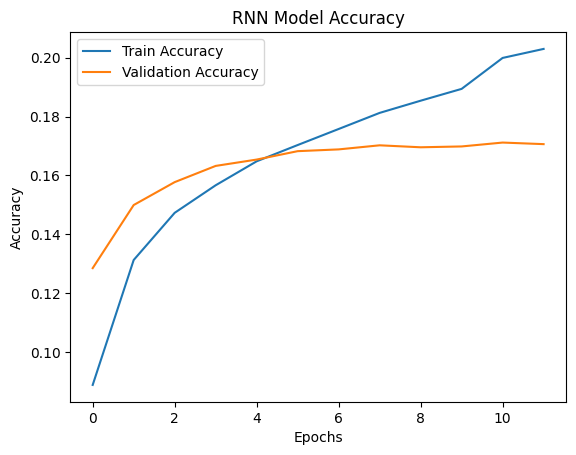

In [44]:
#Accuracy Graph
plt.plot(history_rnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_rnn.history['val_accuracy'], label='Validation Accuracy')

plt.title('RNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

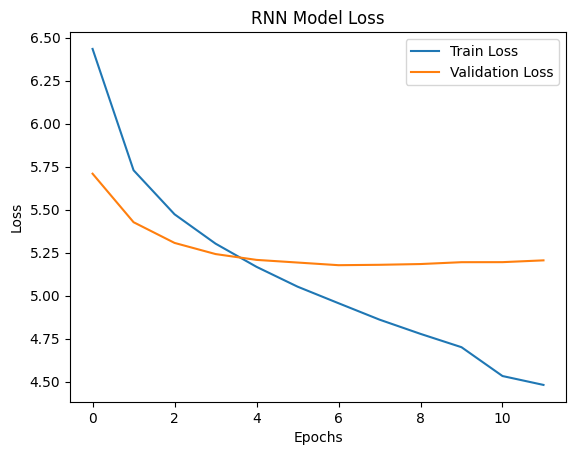

In [45]:
#Loss Graph
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')

plt.title('RNN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 9. GRU

In [50]:
# Build GRU model
tf.keras.backend.clear_session()
gru_model = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=False),
    GRU(RNN_UNITS),
    Dropout(0.4),
    Dense(VOCAB_SIZE, activation='softmax')
], name="GRU_Model")

In [51]:
# Compile model
gru_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

In [52]:
# Build model structure
gru_model.build(input_shape=(None, MAX_LEN))
gru_model.summary()

Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 64)         │       512,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8000)           │     1,032,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,618,496 (6.17 MB)

 Trainable params: 1,618,496 (6.17 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# Train model and measure 
t0 = time.time()
history_gru = gru_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    callbacks=get_callbacks(),
    verbose=1
)
gru_time = time.time() - t0

Epoch 1/50
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.0757 - loss: 6.6522 - val_accuracy: 0.1355 - val_loss: 5.6698 - learning_rate: 0.0010
Epoch 2/50
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.1280 - loss: 5.7462 - val_accuracy: 0.1504 - val_loss: 5.4004 - learning_rate: 0.0010
Epoch 3/50
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.1439 - loss: 5.4773 - val_accuracy: 0.1589 - val_loss: 5.2843 - learning_rate: 0.0010
Epoch 4/50
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.1533 - loss: 5.3184 - val_accuracy: 0.1634 - val_loss: 5.2079 - learning_rate: 0.0010
Epoch 5/50
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.1625 - loss: 5.1633 - val_accuracy: 0.1678 - val_loss: 5.1549 - learning_rate: 0.0010
Epoch 6/50
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.1668 - loss: 5.0547 - val_accuracy: 0.1714 - val_loss: 5.1224 - learning_rate: 0.0010
Epoch 7/50
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.1

In [54]:
# Evaluate model performance
_, gru_acc = gru_model.evaluate(X_test_pad, y_test, verbose=0)
print(f"\nGRU | Test Accuracy: {gru_acc*100:.2f}% | Time: {gru_time:.1f}s")



GRU | Test Accuracy: 17.74% | Time: 217.4s


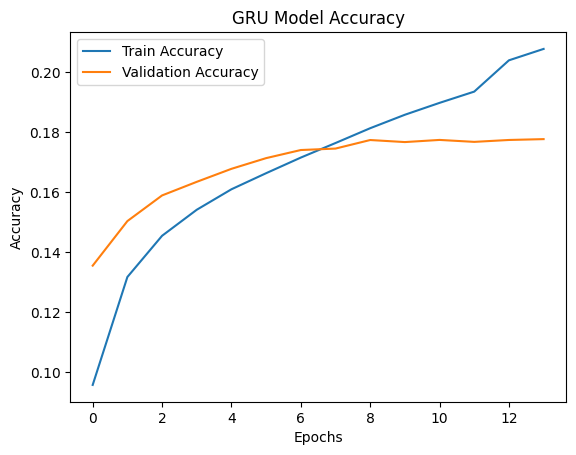

In [72]:
#Accuracy Graph
plt.plot(history_gru.history['accuracy'], label='Train Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='Validation Accuracy')

plt.title('GRU Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

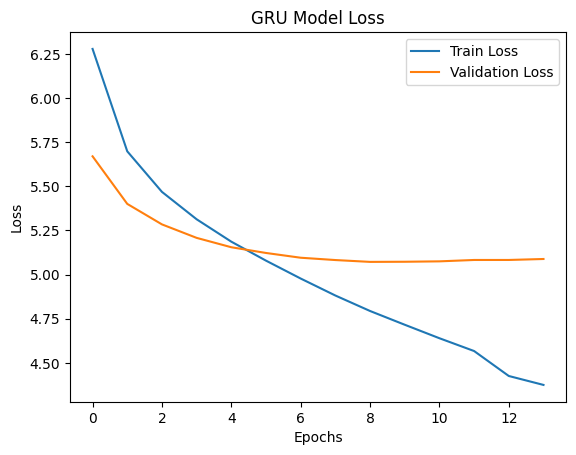

In [73]:
#Loss Graph
plt.plot(history_gru.history['loss'], label='Train Loss')
plt.plot(history_gru.history['val_loss'], label='Validation Loss')

plt.title('GRU Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 10. LSTM

In [55]:
# Build lstm model
tf.keras.backend.clear_session()
lstm_model = Sequential([
    Embedding(VOCAB_SIZE, EMBEDDING_DIM, mask_zero=False),
    LSTM(RNN_UNITS),
    Dropout(0.4),
    Dense(VOCAB_SIZE, activation='softmax')
], name="LSTM_Model")

In [56]:
# Compile model
lstm_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

In [57]:
# Build model structure
lstm_model.build(input_shape=(None, MAX_LEN))
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 30, 64)         │       512,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8000)           │     1,032,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,642,816 (6.27 MB)

 Trainable params: 1,642,816 (6.27 MB)

 Non-trainable params: 0 (0.00 B)

In [58]:
# Train model and measure

t0 = time.time()
history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    callbacks=get_callbacks(),
    verbose=1
)
lstm_time = time.time() - t0

Epoch 1/50
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.0705 - loss: 6.7080 - val_accuracy: 0.1243 - val_loss: 5.8225 - learning_rate: 0.0010
Epoch 2/50
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.1204 - loss: 5.8883 - val_accuracy: 0.1419 - val_loss: 5.5296 - learning_rate: 0.0010
Epoch 3/50
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.1363 - loss: 5.6052 - val_accuracy: 0.1511 - val_loss: 5.3858 - learning_rate: 0.0010
Epoch 4/50
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.1457 - loss: 5.4159 - val_accuracy: 0.1574 - val_loss: 5.2886 - learning_rate: 0.0010
Epoch 5/50
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.1528 - loss: 5.2722 - val_accuracy: 0.1612 - val_loss: 5.2267 - learning_rate: 0.0010
Epoch 6/50
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.1593 - loss: 5.1639 - val_accuracy: 0.1668 - val_loss: 5.1883 - learning_rate: 0.0010
Epoch 7/50
1901/1901 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.1

In [59]:
# Evaluate model performance
_, lstm_acc = lstm_model.evaluate(X_test_pad, y_test, verbose=0)
print(f"\nLSTM | Test Accuracy: {lstm_acc*100:.2f}% | Time: {lstm_time:.1f}s")


LSTM | Test Accuracy: 17.51% | Time: 236.7s


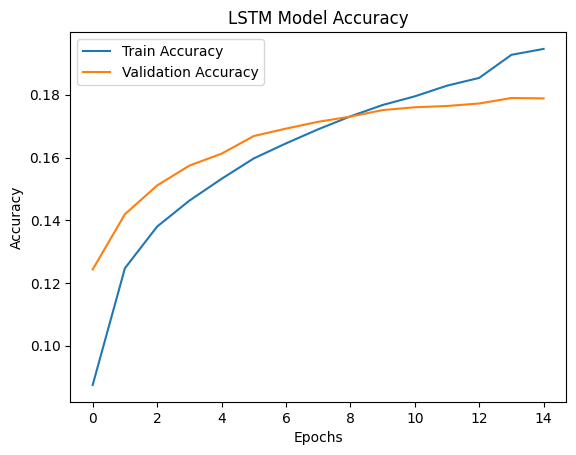

In [60]:
#Accuracy Graph
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')

plt.title('LSTM Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

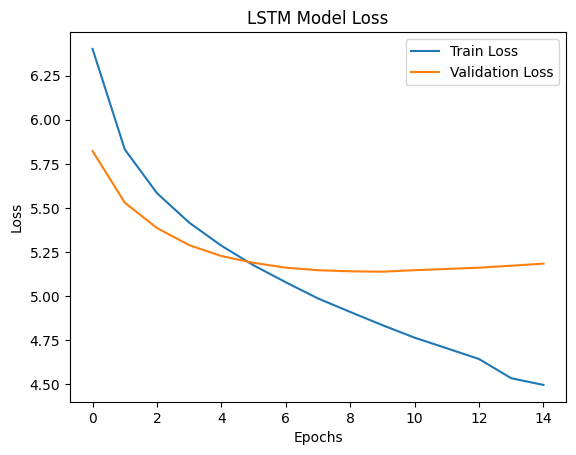

In [61]:
#Loss Graph
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')

plt.title('LSTM Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

#  ***Comparison***

## 11. Combined Final Results Summary(Top-1 Accuracy)

In [62]:
print("Model        Type            Accuracy     Time")
print(f"Bigram       Classical       {bigram_acc*100:.2f}%      N/A")
print(f"Trigram      Classical       {trigram_acc*100:.2f}%      N/A")
print(f"Naive Bayes  ML              {nb_acc*100:.2f}%      N/A")
print(f"Simple RNN   DL      \t{rnn_acc*100:.2f}%      \t{rnn_time:.1f}s")
print(f"GRU          DL        \t{gru_acc*100:.2f}%      \t{gru_time:.1f}s")
print(f"LSTM         DL       \t{lstm_acc*100:.2f}%      \t{lstm_time:.1f}s")

Model        Type            Accuracy     Time
Bigram       Classical       14.27%      N/A
Trigram      Classical       15.49%      N/A
Naive Bayes  ML              7.25%      N/A
Simple RNN   DL      	16.88%      	129.5s
GRU          DL        	17.74%      	217.4s
LSTM         DL       	17.51%      	236.7s


## 12. DL Prediction Helper

In [63]:
def predict_simple(model, text):
    seq = tokenizer.texts_to_sequences([clean_text(text)])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='pre')
    pred = model.predict(pad, verbose=0)
    return index_word.get(np.argmax(pred), '?')

## 13. Qualitative Comparison (All 6 Models)

In [71]:
test_phrases = [
    ("life is",    "life",    "is", None),
    ("love is",    "love",    "is", None),
    ("success is", "success", "is", None),
    ("Rimi is sad",    "Rimi",    "is",    "sad")
]


for phrase, w1, w2, w3 in test_phrases:
    print("\nInput:", phrase)
    print("Bigram     :", predict_bigram(w2))
    print("Trigram    :", predict_trigram(w1, w2))
    print("NaiveBayes :", predict_next_word_nb(phrase))
    print("RNN  :", predict_simple(rnn_model, phrase))
    print("GRU  :", predict_simple(gru_model, phrase))
    print("LSTM :", predict_simple(lstm_model, phrase))


Input: life is
Bigram     : a
Trigram    : a
NaiveBayes : in
RNN  : a
GRU  : a
LSTM : a

Input: love is
Bigram     : a
Trigram    : nt
NaiveBayes : this
RNN  : a
GRU  : a
LSTM : a

Input: success is
Bigram     : a
Trigram    : a
NaiveBayes : to
RNN  : a
GRU  : <OOV>
LSTM : a

Input: Rimi is sad
Bigram     : a
Trigram    : a
NaiveBayes : of
RNN  : by
GRU  : and
LSTM : <OOV>


In [69]:
# Take input from user
phrase = input("Enter phrase: ")

# Clean and split into words
words = phrase.strip().split()
w1 = words[-2] if len(words) >= 2 else None
w2 = words[-1] if len(words) >= 1 else ""

print("\nInput:", phrase)
print("Bigram     :", predict_bigram(w2))
print("Trigram    :", predict_trigram(w1, w2))
print("NaiveBayes :", predict_next_word_nb(phrase))
print("RNN  :", predict_simple(rnn_model, phrase))
print("GRU  :", predict_simple(gru_model, phrase))
print("LSTM :", predict_simple(lstm_model, phrase))

Enter phrase:  i am at my worst



Input: i am at my worst
Bigram     : of
Trigram    : of
NaiveBayes : i
RNN  : time
GRU  : guys
LSTM : place


## 14. Accuracy graph Comparison

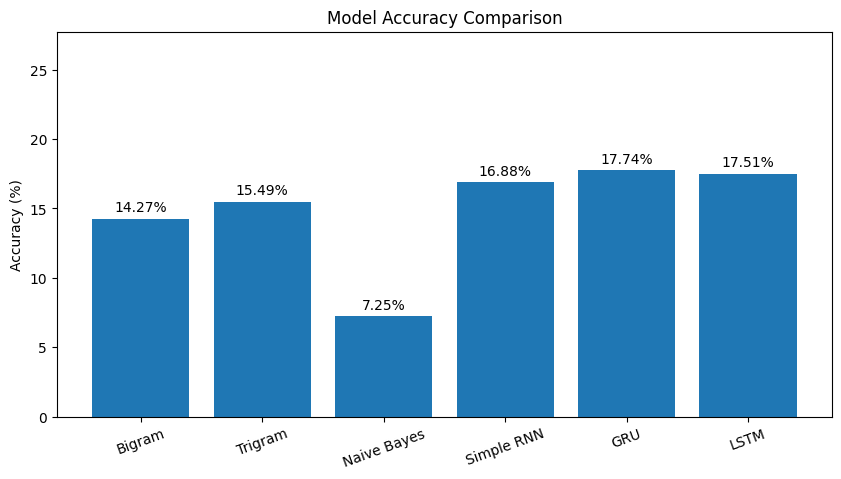

In [66]:
models = ['Bigram', 'Trigram', 'Naive Bayes', 'Simple RNN', 'GRU', 'LSTM']
accuracies = [
    bigram_acc * 100,
    trigram_acc * 100,
    nb_acc * 100,
    rnn_acc * 100,
    gru_acc * 100,
    lstm_acc * 100
]
plt.figure(figsize=(10,5))
plt.bar(models, accuracies)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.ylim(0, max(accuracies) + 10)
plt.xticks(rotation=20)
plt.show()

## 15. Perplexity(DL)

In [67]:
def perplexity(model, X, y):
    loss, _ = model.evaluate(X, y, verbose=0)
    return np.exp(loss)

In [68]:
print("RNN Perplexity :", perplexity(rnn_model, X_test_pad, y_test))
print("GRU Perplexity :", perplexity(gru_model, X_test_pad, y_test))
print("LSTM Perplexity:", perplexity(lstm_model, X_test_pad, y_test))

RNN Perplexity : 177.24571042541254
GRU Perplexity : 159.483112339848
LSTM Perplexity: 170.37630476580506


#  ***Save all the model***

In [74]:
rnn_model.save("rnn_model.keras",   save_format="keras")
gru_model.save("gru_model.keras",   save_format="keras")
lstm_model.save("lstm_model.keras", save_format="keras")

In [75]:
import os
print(os.path.exists("rnn_model.keras"))
print(os.path.exists("gru_model.keras"))
print(os.path.exists("lstm_model.keras"))

True
True
True


In [76]:
#load the model
from tensorflow.keras.models import load_model

rnn_model  = load_model("rnn_model.keras")
gru_model  = load_model("gru_model.keras")
lstm_model = load_model("lstm_model.keras")

In [77]:
# Save Naive Bayes model and TF-IDF vectorizer
import pickle
with open("nb_model.pkl", "wb") as f:
    pickle.dump(nb_model, f)
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

# Save Trigram and Bigram models
with open("trigram_model.pkl", "wb") as f:
    pickle.dump(dict(trigram_model), f)
with open("bigram_model.pkl", "wb") as f:
    pickle.dump(dict(bigram_model), f)

print("Naive Bayes model saved    : nb_model.pkl")
print("TF-IDF vectorizer saved    : tfidf_vectorizer.pkl")
print("Trigram model saved        : trigram_model.pkl")
print("Bigram model saved         : bigram_model.pkl")

Naive Bayes model saved    : nb_model.pkl
TF-IDF vectorizer saved    : tfidf_vectorizer.pkl
Trigram model saved        : trigram_model.pkl
Bigram model saved         : bigram_model.pkl


In [78]:
print(os.path.exists("nb_model.pkl"))
print(os.path.exists("tfidf_vectorizer.pkl"))
print(os.path.exists("trigram_model.pkl"))
print(os.path.exists("bigram_model.pkl"))

True
True
True
True


In [79]:
#load the model
nb_model   = pickle.load(open("nb_model.pkl",        "rb"))
vectorizer = pickle.load(open("tfidf_vectorizer.pkl", "rb"))

trigram_model = defaultdict(lambda: defaultdict(float),
    {k: defaultdict(float, v) for k, v in pickle.load(open("trigram_model.pkl", "rb")).items()})

bigram_model  = defaultdict(lambda: defaultdict(float),
    {k: defaultdict(float, v) for k, v in pickle.load(open("bigram_model.pkl",  "rb")).items()})

In [81]:
# ML helper functions
def predict_next_word_nb(text):
    vec = vectorizer.transform([clean_text(text)])
    return nb_model.predict(vec)[0]

def predict_bigram(word):
    if word in bigram_model:
        return max(bigram_model[word], key=bigram_model[word].get)
    return "<unknown>"

def predict_trigram(w1, w2):
    if (w1, w2) in trigram_model:
        return max(trigram_model[(w1, w2)], key=trigram_model[(w1, w2)].get)
    return predict_bigram(w2)

In [85]:
# DL helper function
def predict_dl(text, model):
    seq = tokenizer.texts_to_sequences([clean_text(text)])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding="pre")
    pred = model.predict(pad, verbose=0)
    top3_idx   = np.argsort(pred[0])[-3:][::-1]
    top3_words = [index_word.get(i, "?") for i in top3_idx]
    top3_probs = [pred[0][i] * 100 for i in top3_idx]
    return top3_words, top3_probs

In [86]:
models = {
    "RNN" : rnn_model,
    "GRU" : gru_model,
    "LSTM": lstm_model
}

In [87]:
dummy = pad_sequences([[1]], maxlen=MAX_LEN, padding="pre")
for model in models.values():
    model.predict(dummy, verbose=0)

In [88]:
while True:
    phrase = input("\nPhrase (q to quit): ").strip()
    if phrase.lower() == "q":
        break

    words = clean_text(phrase).split()
    w1 = words[-2] if len(words) >= 2 else words[0]
    w2 = words[-1]

    print(f"\nInput : '{phrase}'")
    print(f"Bigram      : {predict_bigram(w2)}")
    print(f"Trigram     : {predict_trigram(w1, w2)}")
    print(f"Naive Bayes : {predict_next_word_nb(phrase)}")
    for name, model in models.items():
        words_pred, probs = predict_dl(phrase, model)
        print(f"{name:<12}: {words_pred[0]}")


Phrase (q to quit):  life is too short



Input : 'life is too short'
Bigram      : time
Trigram     : and
Naive Bayes : much
RNN         : and
GRU         : and
LSTM        : and



Phrase (q to quit):  i am not feeling



Input : 'i am not feeling'
Bigram      : the
Trigram     : the
Naive Bayes : i
RNN         : that
GRU         : a
LSTM        : that



Phrase (q to quit):  even the moon takes


...


Phrase (q to quit):  even at my worst



Input : 'even at my worst'
Bigram      : of
Trigram     : of
Naive Bayes : case
RNN         : time
GRU         : <OOV>
LSTM        : time



Phrase (q to quit):  i know my worth of



Input : 'i know my worth of'
Bigram      : the
Trigram     : combat
Naive Bayes : it
RNN         : the
GRU         : the
LSTM        : the



Phrase (q to quit):  q


## Note: Due to GPU memory limitations in the Kaggle free-tier environment, the Top-K accuracy could not be computed at runtime. The GPU exhausted available memory when attempting to run inference over the full test set, even with reduced batch sizes. 